# structured / IMG_5983

このノートブックは、1本の動画についてフレーム確認、歪み補正の試行、ORB特徴点検出、隣接フレームのマッチング、特徴量ファイルの確認を行うための作業場所です。

In [1]:
from pathlib import Path
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'scripts').exists():
            return candidate
    raise RuntimeError('Run this notebook from inside the my-research project.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SEQUENCE = 'structured/IMG_5983'
FRAMES_ROOT = PROJECT_ROOT / 'data' / 'interim' / 'frames_10fps'
FEATURES_ROOT = PROJECT_ROOT / 'results' / 'orb_features_n1000'
BUDGET_CSV = PROJECT_ROOT / 'results' / 'feature_budgets' / 'summary.csv'
CAMERA_CONFIG = PROJECT_ROOT / 'configs' / 'orbslam3' / 'iphone_vertical_1080x1920_approx.yaml'

sequence_dir = FRAMES_ROOT / SEQUENCE
frame_paths = sorted(sequence_dir.glob('frame_*.jpg'))
metadata_path = sequence_dir / 'metadata.json'
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'SEQUENCE: {SEQUENCE}')
print(f'frames: {len(frame_paths)}')
metadata


PROJECT_ROOT: /Users/otsukamashu/univ-research/my-research
SEQUENCE: structured/IMG_5983
frames: 160


{'video': 'structured/IMG_5983.MOV',
 'status': 'ok',
 'target_fps': 10.0,
 'source_fps': 30.003132,
 'source_frames': 479,
 'source_width': 1080,
 'source_height': 1920,
 'source_duration_sec': 15.965,
 'frames_written': 160}

## 代表フレーム

動画全体から等間隔にフレームを抜き出して、撮影状況を確認します。

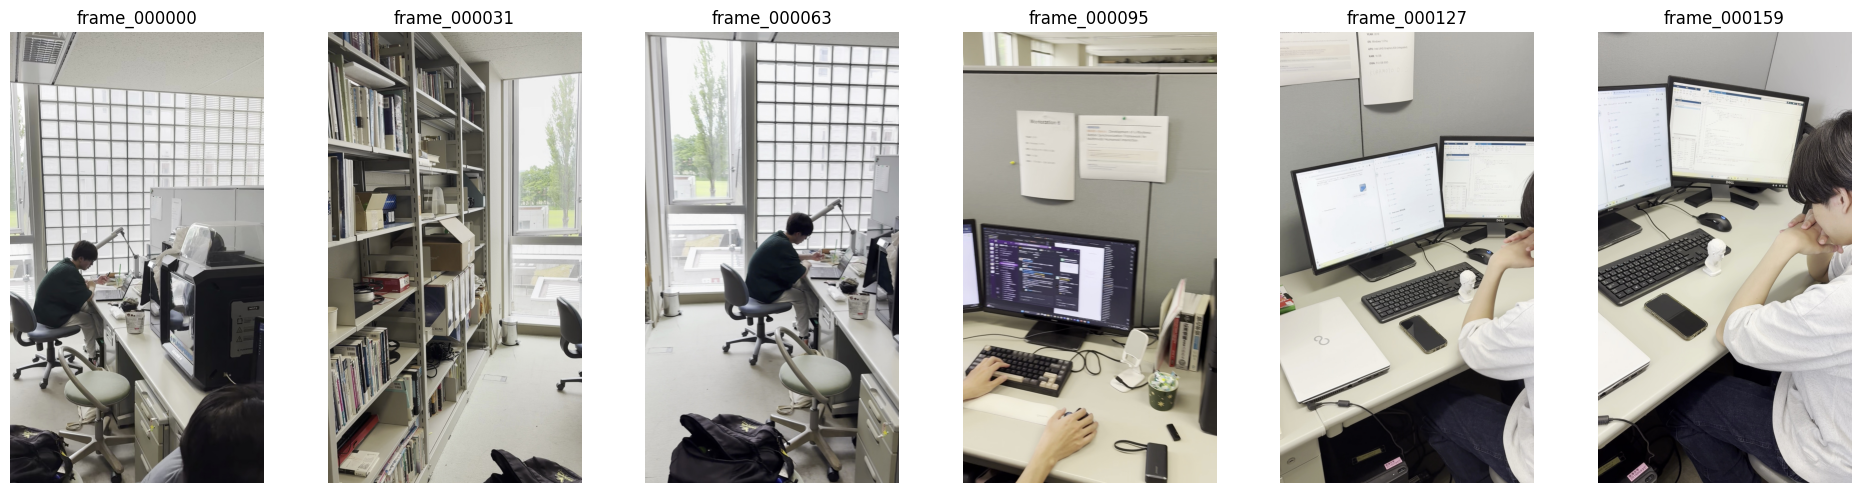

In [2]:
if not frame_paths:
    raise FileNotFoundError(f'No frames found in {sequence_dir}')

indices = np.linspace(0, len(frame_paths) - 1, min(6, len(frame_paths)), dtype=int)
fig, axes = plt.subplots(1, len(indices), figsize=(3.2 * len(indices), 5))
if len(indices) == 1:
    axes = [axes]
for ax, index in zip(axes, indices):
    image = cv2.imread(str(frame_paths[index]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax.imshow(image)
    ax.set_title(frame_paths[index].stem)
    ax.axis('off')
plt.tight_layout()


## 特徴点数と通信量の概要

`scripts/evaluate_feature_budgets.py` の結果から、この動画の特徴点予算ごとの概算を見ます。

In [3]:
budget = pd.read_csv(BUDGET_CSV)
sequence_budget = budget[budget['sequence'] == SEQUENCE].copy()
sequence_budget


,sequence,frames,nfeatures,avg_keypoints,min_keypoints,p10_keypoints,p90_keypoints,max_keypoints,avg_matches_to_previous,avg_good_matches_to_previous,avg_match_distance,avg_descriptor_bytes_per_frame,avg_compact_packet_bytes_per_frame,avg_float_packet_bytes_per_frame,avg_jpeg_bytes_per_frame,compact_packet_vs_jpeg_ratio
4,structured/IMG_5983,160,250,250.0,250,250.0,250.0,250,164.308,162.660,21.267,8000.0,10250.0,14000.0,429428.006,0.0239
12,structured/IMG_5983,160,500,500.0,500,500.0,500.0,500,325.868,323.289,21.546,16000.0,20500.0,28000.0,429428.006,0.0477
20,structured/IMG_5983,160,1000,1000.0,1000,1000.0,1000.0,1000,643.333,638.925,21.852,32000.0,41000.0,56000.0,429428.006,0.0955
28,structured/IMG_5983,160,2000,2000.0,2000,2000.0,2000.0,2000,1260.151,1251.755,22.056,64000.0,82000.0,112000.0,429428.006,0.1910


In [4]:
columns = [
    'nfeatures',
    'avg_keypoints',
    'avg_good_matches_to_previous',
    'avg_compact_packet_bytes_per_frame',
    'avg_jpeg_bytes_per_frame',
    'compact_packet_vs_jpeg_ratio',
]
sequence_budget[columns]


,nfeatures,avg_keypoints,avg_good_matches_to_previous,avg_compact_packet_bytes_per_frame,avg_jpeg_bytes_per_frame,compact_packet_vs_jpeg_ratio
4,250,250.0,162.660,10250.0,429428.006,0.0239
12,500,500.0,323.289,20500.0,429428.006,0.0477
20,1000,1000.0,638.925,41000.0,429428.006,0.0955
28,2000,2000.0,1251.755,82000.0,429428.006,0.1910


## ORB特徴点の可視化

`frame_index` と `nfeatures` を変えると、別フレームや別の特徴点数で確認できます。

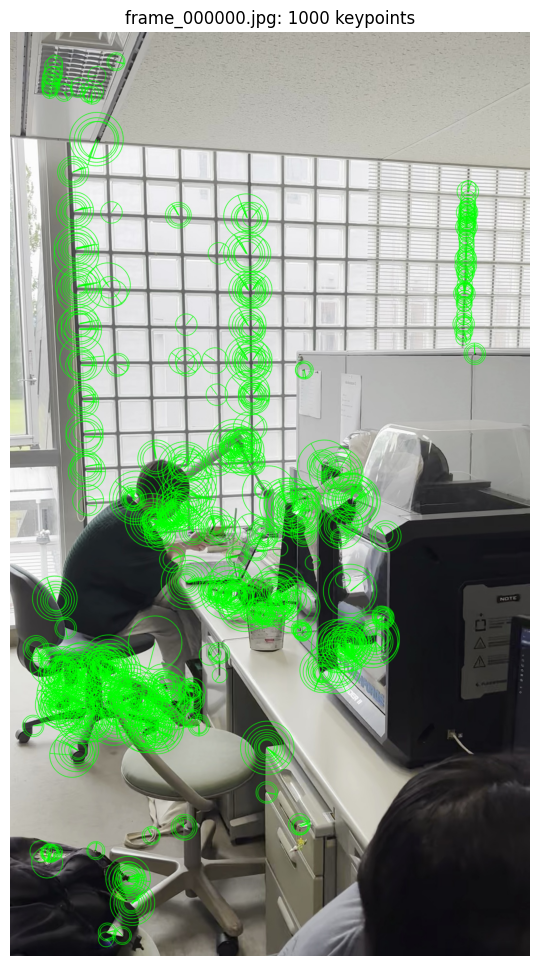

(1000, (1000, 32))

In [13]:
frame_index = 0
nfeatures = 1000

image_bgr = cv2.imread(str(frame_paths[frame_index]))
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
orb = cv2.ORB_create(nfeatures=nfeatures)
keypoints, descriptors = orb.detectAndCompute(gray, None)
vis = cv2.drawKeypoints(
    image_bgr,
    keypoints,
    None,
    color=(0, 255, 0),
    flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS,
)

plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'{frame_paths[frame_index].name}: {len(keypoints)} keypoints')
plt.axis('off')
plt.show()

len(keypoints), None if descriptors is None else descriptors.shape


## 歪み補正の試行

ここでは処理の流れを確認するため、仮の内部パラメータとゼロ歪み係数を使っています。正確な歪み補正には、チェッカーボード等で実測したカメラキャリブレーション結果に置き換えてください。

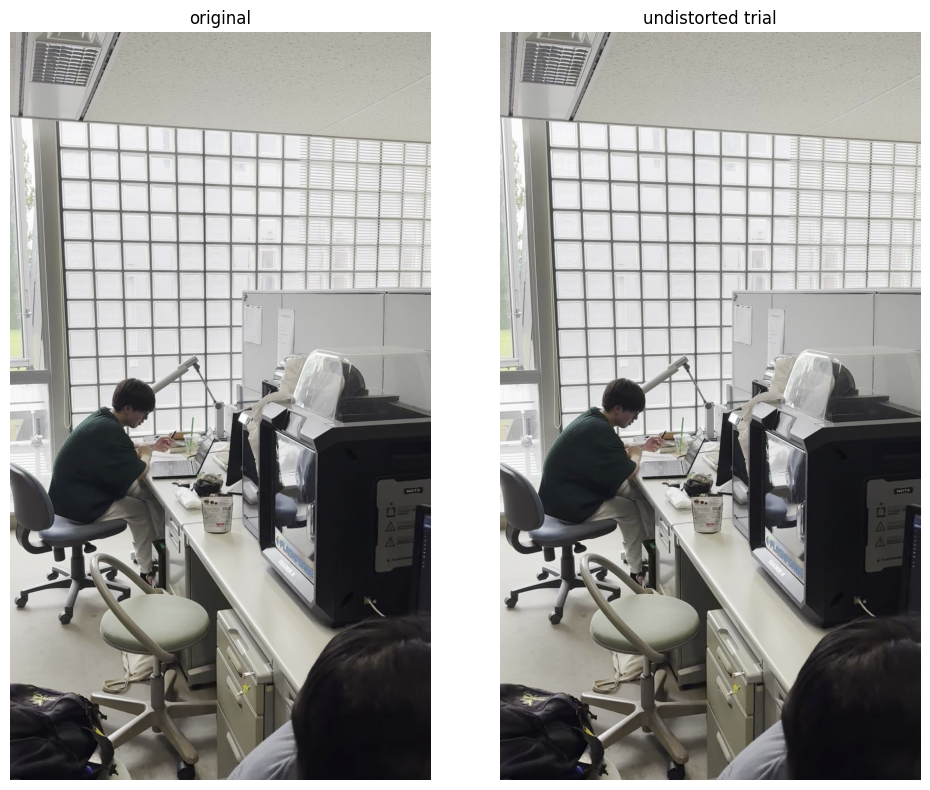

In [6]:
height, width = image_bgr.shape[:2]
camera_matrix = np.array(
    [[1500.0, 0.0, width / 2], [0.0, 1500.0, height / 2], [0.0, 0.0, 1.0]],
    dtype=np.float32,
)
dist_coeffs = np.zeros(5, dtype=np.float32)
undistorted = cv2.undistort(image_bgr, camera_matrix, dist_coeffs)

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
axes[1].set_title('undistorted trial')
axes[1].axis('off')
plt.tight_layout()


## 隣接フレームのマッチング

隣り合う2フレーム間でORB特徴量を対応付け、追跡しやすい映像かを確認します。

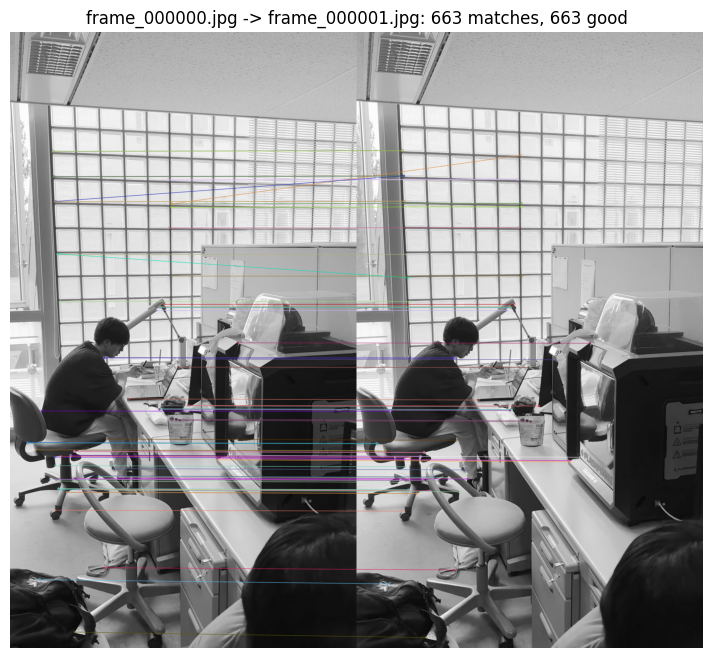

(1000, 1000, 663, 663)

In [7]:
i = 0
j = min(i + 1, len(frame_paths) - 1)
img1_gray = cv2.imread(str(frame_paths[i]), cv2.IMREAD_GRAYSCALE)
img2_gray = cv2.imread(str(frame_paths[j]), cv2.IMREAD_GRAYSCALE)

kp1, des1 = orb.detectAndCompute(img1_gray, None)
kp2, des2 = orb.detectAndCompute(img2_gray, None)
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = [] if des1 is None or des2 is None else matcher.match(des1, des2)
matches = sorted(matches, key=lambda match: match.distance)
good_matches = [match for match in matches if match.distance <= 64]

drawn = cv2.drawMatches(
    img1_gray,
    kp1,
    img2_gray,
    kp2,
    matches[:80],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
plt.figure(figsize=(14, 8))
plt.imshow(drawn, cmap='gray')
plt.title(f'{frame_paths[i].name} -> {frame_paths[j].name}: {len(matches)} matches, {len(good_matches)} good')
plt.axis('off')
plt.show()

len(kp1), len(kp2), len(matches), len(good_matches)


## 保存済み特徴量ファイルの確認

`scripts/export_orb_features.py` で作った `.npz` を読み込み、送信対象になる特徴点と記述子を確認します。

In [8]:
feature_file = FEATURES_ROOT / SEQUENCE / f'{frame_paths[frame_index].stem}.npz'
with np.load(feature_file) as feature_data:
    saved_keypoints = feature_data['keypoints']
    saved_descriptors = feature_data['descriptors']

feature_file, saved_keypoints.shape, saved_descriptors.shape, saved_descriptors.dtype


(PosixPath('/Users/otsukamashu/univ-research/my-research/results/orb_features_n1000/structured/IMG_5983/frame_000000.npz'),
 (1000, 7),
 (1000, 32),
 dtype('uint8'))

## Essential Matrixの最小確認

仮のカメラ内部パラメータなので、ここでの値は精度評価ではなく、処理パイプラインの確認用です。

In [9]:
if len(matches) >= 8:
    pts1 = np.float32([kp1[match.queryIdx].pt for match in matches])
    pts2 = np.float32([kp2[match.trainIdx].pt for match in matches])
    essential_matrix, inlier_mask = cv2.findEssentialMat(
        pts1,
        pts2,
        camera_matrix,
        method=cv2.RANSAC,
        prob=0.999,
        threshold=1.0,
    )
    inliers = int(inlier_mask.sum()) if inlier_mask is not None else 0
else:
    essential_matrix = None
    inliers = 0

inliers, None if essential_matrix is None else essential_matrix.shape


(502, (3, 3))